In [1]:
import pandas as pd 
import numpy as np 
from torchvision import datasets
from torch.utils.data import DataLoader
from collections import Counter
import matplotlib.pyplot as plt

#### Загружаем датасет 

In [2]:
train_dataset = datasets.CIFAR10(
    root="../../data",
    train=True,
    download=True,
)

test_dataset = datasets.CIFAR10(
    root="../../data",
    train=False,
    download=True,
)

<hr>

#### EDA

In [3]:
print(f"Train images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")

Train images: 50000
Test images: 10000


In [4]:
image, label = train_dataset[0]

print(f"Resolution: {image.size}")
print(f"Channels: {len(image.getbands())}")
print(f"Color mode: {image.mode}")

Resolution: (32, 32)
Channels: 3
Color mode: RGB


In [5]:
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
train_labels = train_dataset.targets
test_labels = test_dataset.targets

train_distribution = Counter(train_labels)
test_distribution = Counter(test_labels)

for class_id, class_name in enumerate(train_dataset.classes):
    print(
        f"{class_name:12} "
        f"train={train_distribution[class_id]:5} "
        f"test={test_distribution[class_id]:5}"
    )

airplane     train= 5000 test= 1000
automobile   train= 5000 test= 1000
bird         train= 5000 test= 1000
cat          train= 5000 test= 1000
deer         train= 5000 test= 1000
dog          train= 5000 test= 1000
frog         train= 5000 test= 1000
horse        train= 5000 test= 1000
ship         train= 5000 test= 1000
truck        train= 5000 test= 1000


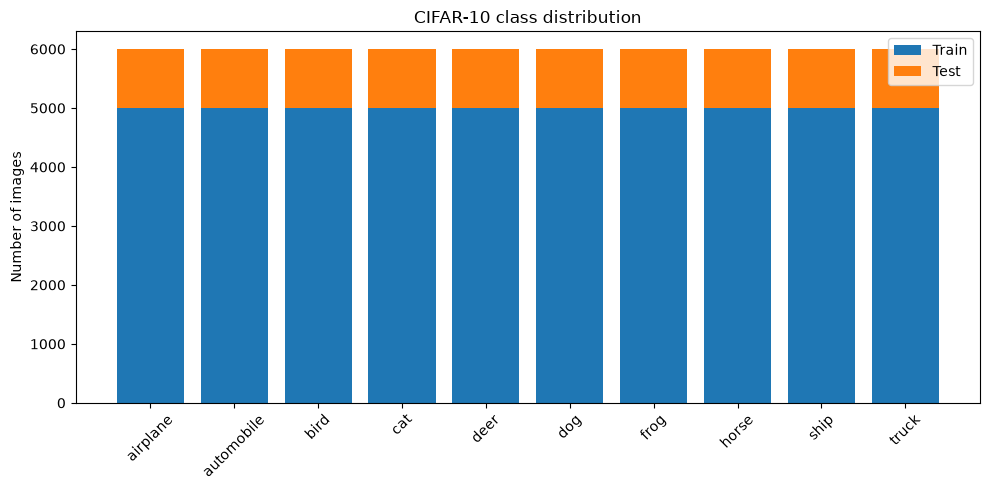

In [7]:
class_names = train_dataset.classes
train_counts = [train_distribution[i] for i in range(10)]


test_counts = [test_distribution[i] for i in range(10)]

x = range(len(class_names))

plt.figure(figsize=(10, 5))

plt.bar(x, train_counts, label="Train")
plt.bar(x, test_counts, bottom=train_counts, label="Test")

plt.xticks(x, class_names, rotation=45)
plt.ylabel("Number of images")
plt.title("CIFAR-10 class distribution")

plt.legend()
plt.tight_layout()
plt.show()

Дисбаланса классов не наблюдается. Посмотрим на 5 экзмепляров каждого класса:

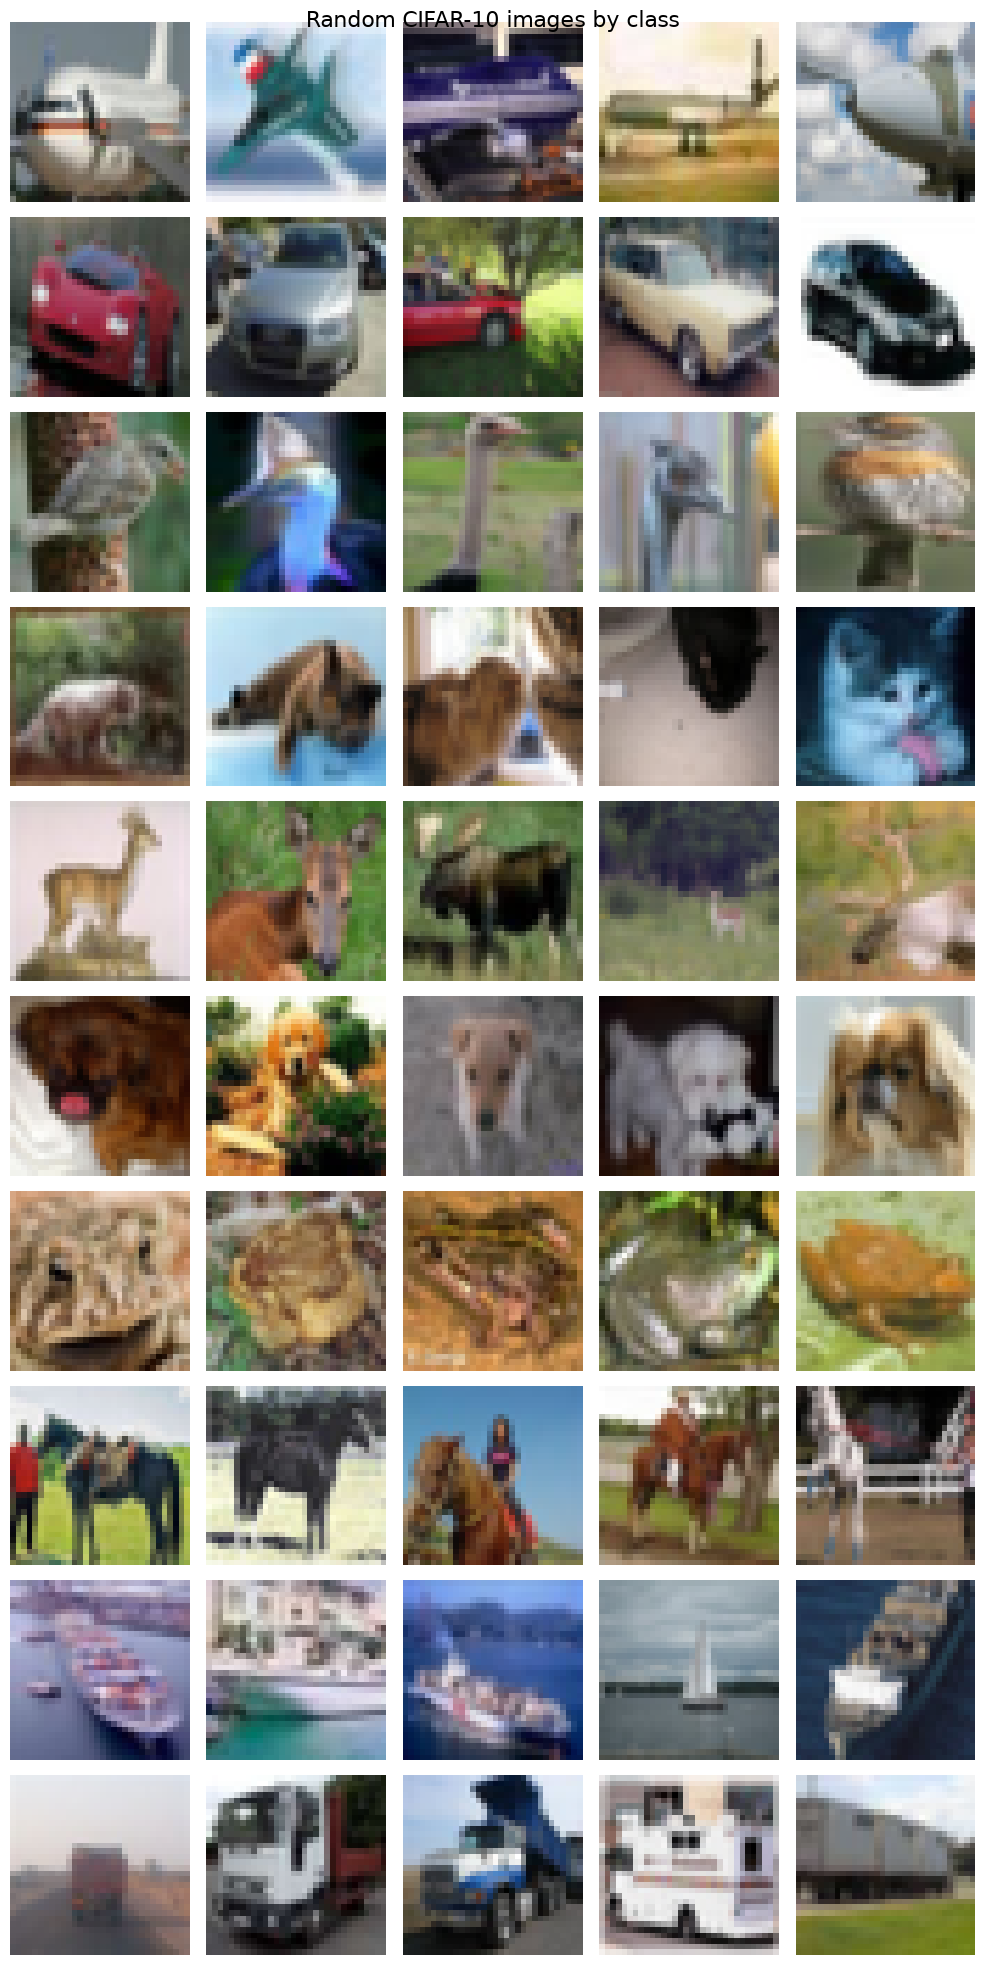

In [8]:
classes = train_dataset.classes

fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=5,
    figsize=(10, 20)
)

for class_id, class_name in enumerate(classes):

    # Индексы изображений текущего класса
    class_indices = np.where(
        np.array(train_dataset.targets) == class_id
    )[0]

    # Случайно выбираем 5 изображений
    selected_indices = np.random.choice(
        class_indices,
        size=5,
        replace=False
    )

    for column, index in enumerate(selected_indices):

        image, label = train_dataset[index]

        axes[class_id, column].imshow(image)
        axes[class_id, column].axis("off")

        if column == 0:
            axes[class_id, column].set_ylabel(
                class_name,
                fontsize=12
            )

plt.suptitle(
    "Random CIFAR-10 images by class",
    fontsize=16
)

plt.tight_layout()
plt.show()